In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

plt.style.use("ggplot")

In [2]:
student_data = pd.read_csv("StudentPerformanceFactors.csv")

student_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
student_data.shape

(6607, 20)

In [4]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
student_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [6]:
student_data.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

The dataset contains academic and lifestyle information related to student performance.

Several variables may influence examination outcomes.

A small number of missing values are present in selected categorical columns.

In [7]:
student_data["Teacher_Quality"].fillna(
    student_data["Teacher_Quality"].mode()[0],
    inplace=True
)

student_data["Parental_Education_Level"].fillna(
    student_data["Parental_Education_Level"].mode()[0],
    inplace=True
)

student_data["Distance_from_Home"].fillna(
    student_data["Distance_from_Home"].mode()[0],
    inplace=True
)

C:\Users\akash\AppData\Local\Temp\ipykernel_13324\352643410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_data["Teacher_Quality"].fillna(
C:\Users\akash\AppData\Local\Temp\ipykernel_13324\352643410.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [9]:
student_data.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [10]:
student_data.duplicated().sum()

np.int64(0)

Missing values were handled successfully using the most frequent category.

No duplicate records were identified.

The dataset is ready for further analysis.

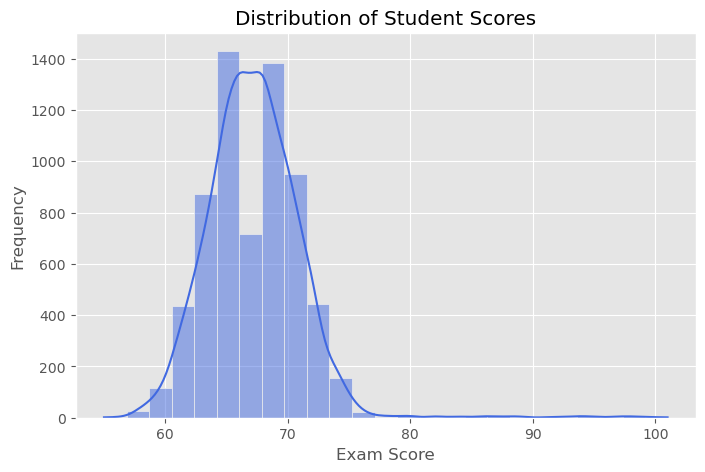

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    student_data["Exam_Score"],
    bins=25,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Student Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

Most students achieved scores around the central range.

The distribution suggests a balanced spread of academic performance.

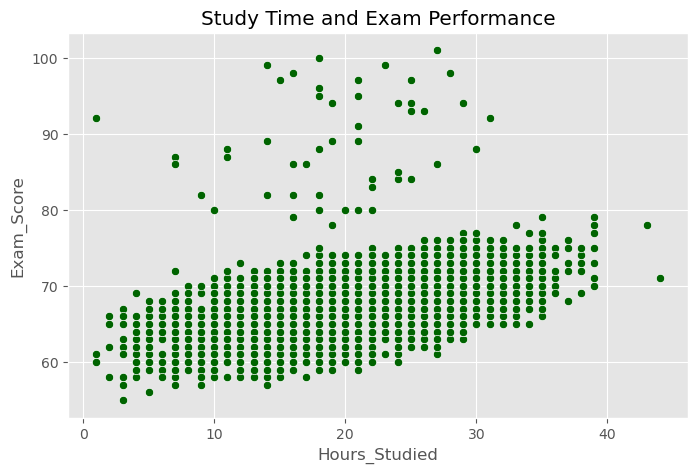

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=student_data,
    x="Hours_Studied",
    y="Exam_Score",
    color="darkgreen"
)

plt.title("Study Time and Exam Performance")

plt.show()

Students who dedicate more hours to studying generally achieve higher scores.

A positive trend can be observed between study effort and performance.

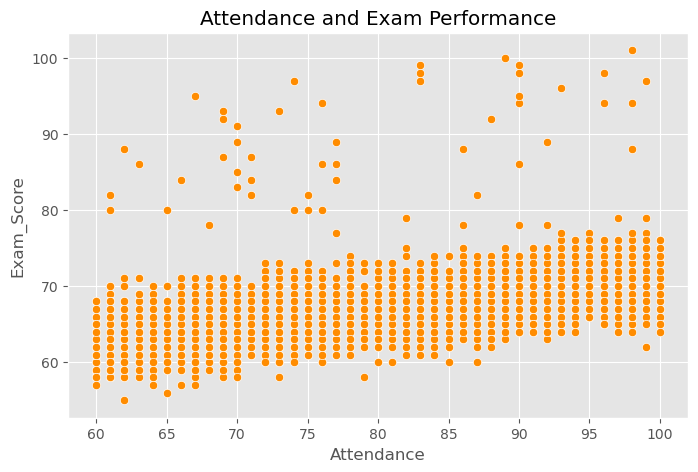

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=student_data,
    x="Attendance",
    y="Exam_Score",
    color="darkorange"
)

plt.title("Attendance and Exam Performance")

plt.show()

Higher attendance levels are associated with improved academic outcomes.

Regular participation appears to contribute positively to student performance.

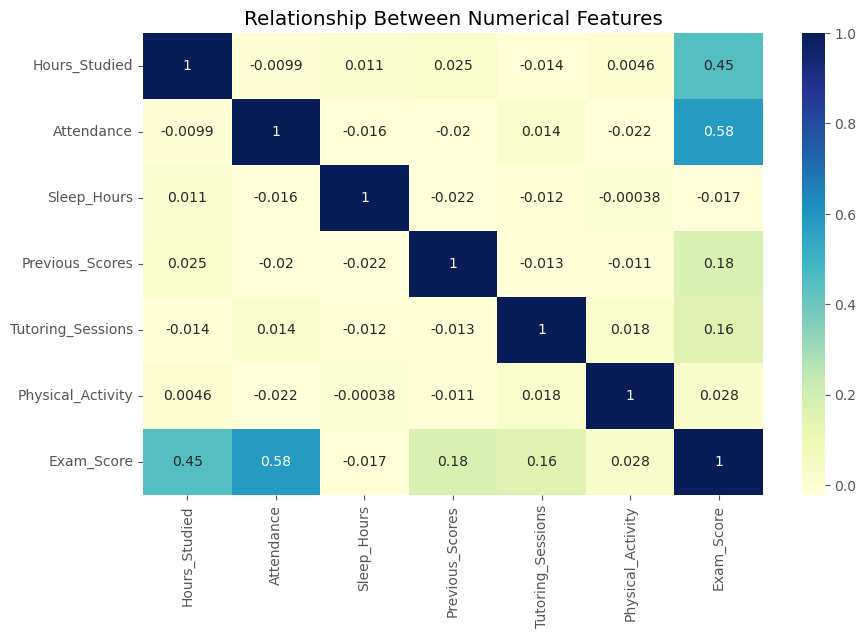

In [16]:
numeric_columns = student_data.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_columns.corr(),
    cmap="YlGnBu",
    annot=True
)

plt.title("Relationship Between Numerical Features")

plt.show()

Attendance and previous academic results show a noticeable relationship with exam performance.

Several numerical features contribute differently to student achievement.

In [17]:
encoder = LabelEncoder()

for column in student_data.select_dtypes(include="object").columns:
    student_data[column] = encoder.fit_transform(
        student_data[column]
    )

student_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


Categorical variables were converted into numerical format.

This transformation allows machine learning algorithms to process the data efficiently.

In [18]:
features = student_data.drop(
    "Exam_Score",
    axis=1
)

target = student_data["Exam_Score"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=7
)

The dataset was divided into training and testing subsets.

Eighty percent of the data was used for training and twenty percent for testing.

In [20]:
regression_model = LinearRegression()

regression_model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


A Linear Regression model was trained using the selected features.

The model learned relationships between student characteristics and exam performance.

In [21]:
predicted_scores = regression_model.predict(
    X_test
)

predicted_scores[:10]

array([67.86326303, 67.23658988, 66.6455488 , 68.9879585 , 73.42790193,
       63.61878519, 70.43147895, 64.24958025, 61.84415828, 71.00293872])

In [22]:
mae_value = mean_absolute_error(
    y_test,
    predicted_scores
)

mse_value = mean_squared_error(
    y_test,
    predicted_scores
)

rmse_value = np.sqrt(mse_value)

r2_value = r2_score(
    y_test,
    predicted_scores
)

print("MAE :", round(mae_value, 2))
print("RMSE :", round(rmse_value, 2))
print("R2 Score :", round(r2_value, 2))

MAE : 1.05
RMSE : 2.32
R2 Score : 0.65


The model achieved satisfactory prediction performance.

The error values remain relatively low, indicating reliable predictions.

The R² score shows that a significant portion of score variation is explained by the model.

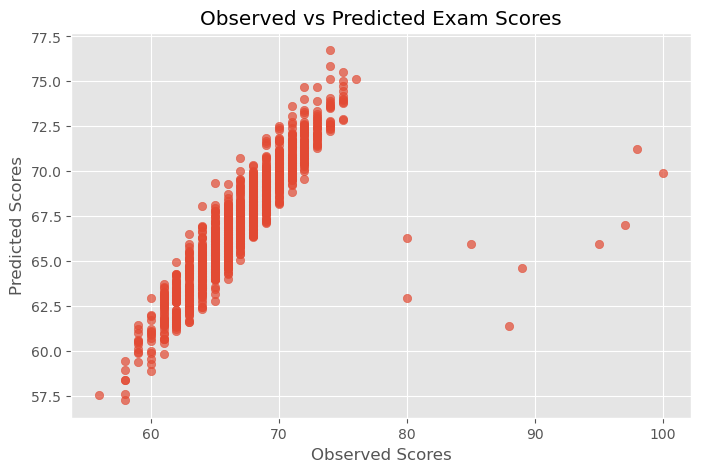

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predicted_scores,
    alpha=0.7
)

plt.xlabel("Observed Scores")
plt.ylabel("Predicted Scores")
plt.title("Observed vs Predicted Exam Scores")

plt.show()

Predicted values closely follow the actual examination scores.

Most observations are concentrated near the expected prediction region.

The model performs consistently across the majority of students.

In [25]:
importance_df = pd.DataFrame({
    "Feature": features.columns,
    "Coefficient": regression_model.coef_
})

importance_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
8,Internet_Access,0.926807
4,Extracurricular_Activities,0.539089
13,Peer_Influence,0.510086
9,Tutoring_Sessions,0.480344
17,Distance_from_Home,0.470163
0,Hours_Studied,0.292894
1,Attendance,0.197823
14,Physical_Activity,0.168817
16,Parental_Education_Level,0.147504
12,School_Type,0.049667


Model coefficients provide insight into feature influence.

Some variables contribute positively while others have a smaller impact on examination outcomes.

A machine learning model was developed to estimate student examination performance using academic, personal, and environmental factors.

Data preprocessing, feature transformation, model training, and evaluation were successfully completed.

The Linear Regression model produced reliable predictions and demonstrated the usefulness of machine learning techniques for educational performance analysis.